<a href="https://colab.research.google.com/github/MaggieHDez/ClassFiles/blob/main/comparativa_255879.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparación de modelos DeepAR, Transformer con Decoder, Transformer sin Decoder y N-BEATS
> **Dataset:** `hour.csv`\
> **Objetivo:** predecir `cnt` con horizonte de 24 horas\
> **Métricas:** `MAE`, `MSE`, `RMSE`, `MAPE` y `sMAPE`\
>**Clase:** Métodos para pronóstico y analítica avanzada\
>**Alumno:** Margarita Cristina Hernández Delgadillo\
>**Matrícula:** 255879\
>**Fecha:** 12 de Mayo de 2026



In [ ]:
!pip install tensorflow -q

In [ ]:
import tensorflow as tf
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


TensorFlow version: 2.20.0
Archivo usado: /content/drive/MyDrive/ClassFiles/Metodos_de_Pronostico/hour.csv
Forma del dataset: (17379, 17)
Tamaño train: 12165
Tamaño val: 2607
Tamaño test: 2607
Número de variables de entrada: 12

Entrenando DeepAR-like


Model: "DeepAR_like"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 24, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 24, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,456 (228.34 KB)

 Trainable params: 58,456 (228.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 42s 169ms/step - loss: 0.6767 - val_loss: 1.0667 - learning_rate: 0.0010
Epoch 2/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 30s 160ms/step - loss: 0.4755 - val_loss: 0.8908 - learning_rate: 0.0010
Epoch 3/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 30s 157ms/step - loss: 0.4015 - val_loss: 0.7286 - learning_rate: 0.0010
Epoch 4/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 30s 157ms/step - loss: 0.3606 - val_loss: 0.6622 - learning_rate: 0.0010
Epoch 5/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 41s 156ms/step - loss: 0.3335 - val_loss: 0.5809 - learning_rate: 0.0010
Epoch 6/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 30s 159ms/step - loss: 0.3182 - val_loss: 0.6051 - learning_rate: 0.0010
Epoch 7/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 29s 154ms/step - loss: 0.3055 - val_loss: 0.6108 - learning_rate: 0.0010
Epoch 8/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 31s 163ms/step - loss: 0.2939 - val_loss: 0.5772 - learning_rate: 0.0010
Epoch 9/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - loss: 0.2856 - val_loss: 0.550

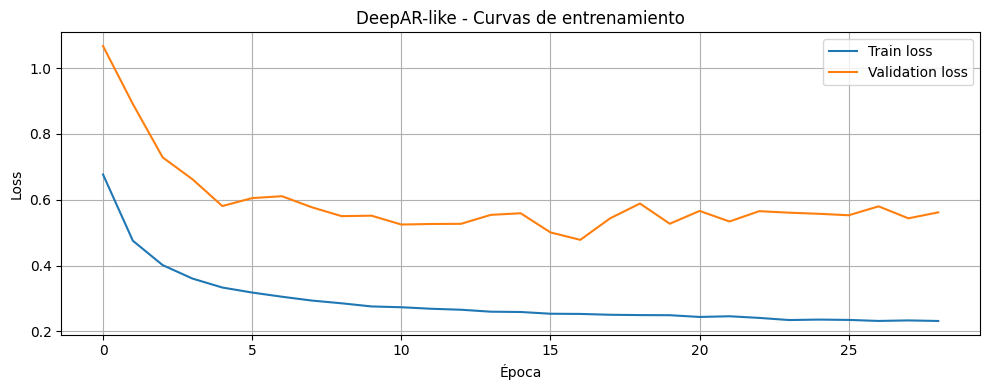

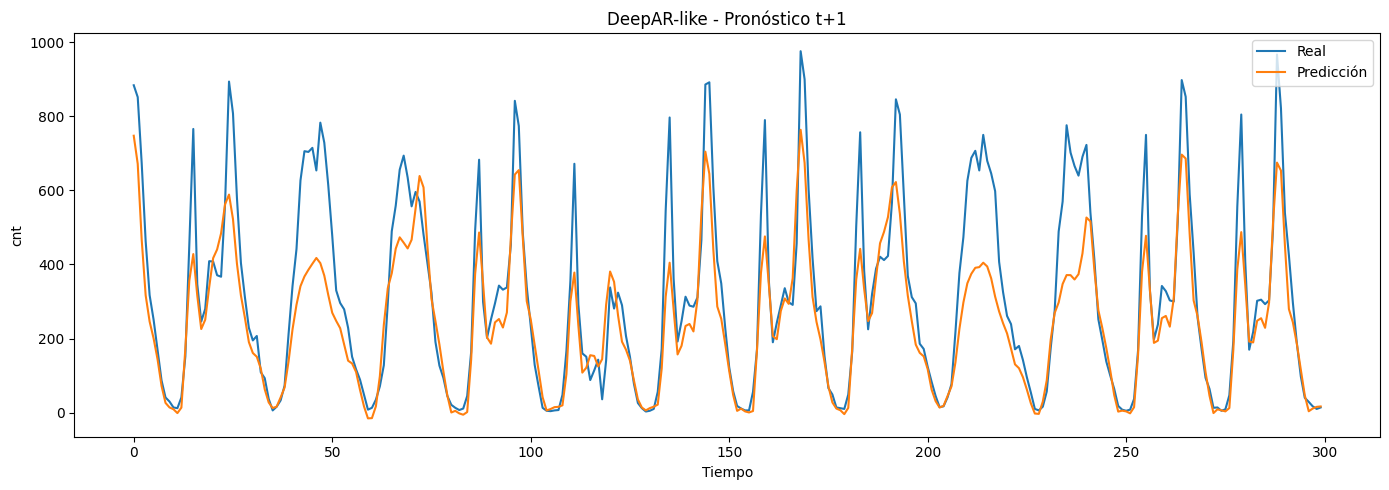


Entrenando Transformer con decoder


Model: "Transformer_con_decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 24, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 24, 64)    │        832 │ encoder_inputs[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 24, 64)    │          0 │ dense_6[0][0]     │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 24, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 24, 64)    │          0 │ dropout_7[0][0],  │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 24, 128)   │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 24, 64)    │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 24, 64)    │          0 │ dense_8[0][0],    │
│                     │                   │            │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 24, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 24, 64)    │        128 │ decoder_inputs[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 24, 64)    │          0 │ dropout_10[0][0], │
│                     │                   │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 24, 64)    │          0 │ dense_11[0][0]  

 Total params: 168,577 (658.50 KB)

 Trainable params: 168,577 (658.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 50s 103ms/step - loss: 0.4805 - val_loss: 0.6216 - learning_rate: 1.0000e-04
Epoch 2/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.3174 - val_loss: 0.5730 - learning_rate: 1.0000e-04
Epoch 3/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.2842 - val_loss: 0.5407 - learning_rate: 1.0000e-04
Epoch 4/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2636 - val_loss: 0.5162 - learning_rate: 1.0000e-04
Epoch 5/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2481 - val_loss: 0.4903 - learning_rate: 1.0000e-04
Epoch 6/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2366 - val_loss: 0.4606 - learning_rate: 1.0000e-04
Epoch 7/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2266 - val_loss: 0.4338 - learning_rate: 1.0000e-04
Epoch 8/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2169 - val_loss: 0.4068 - learning_rate: 1.0000e-04
Epoch 9/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2069 - val_l

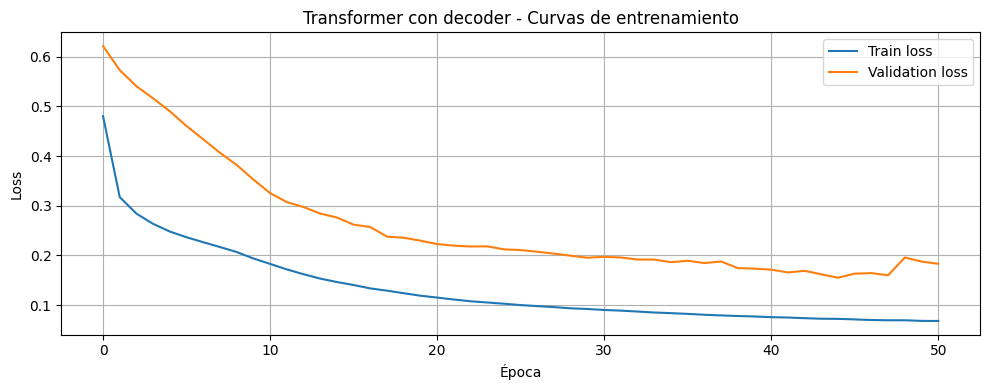

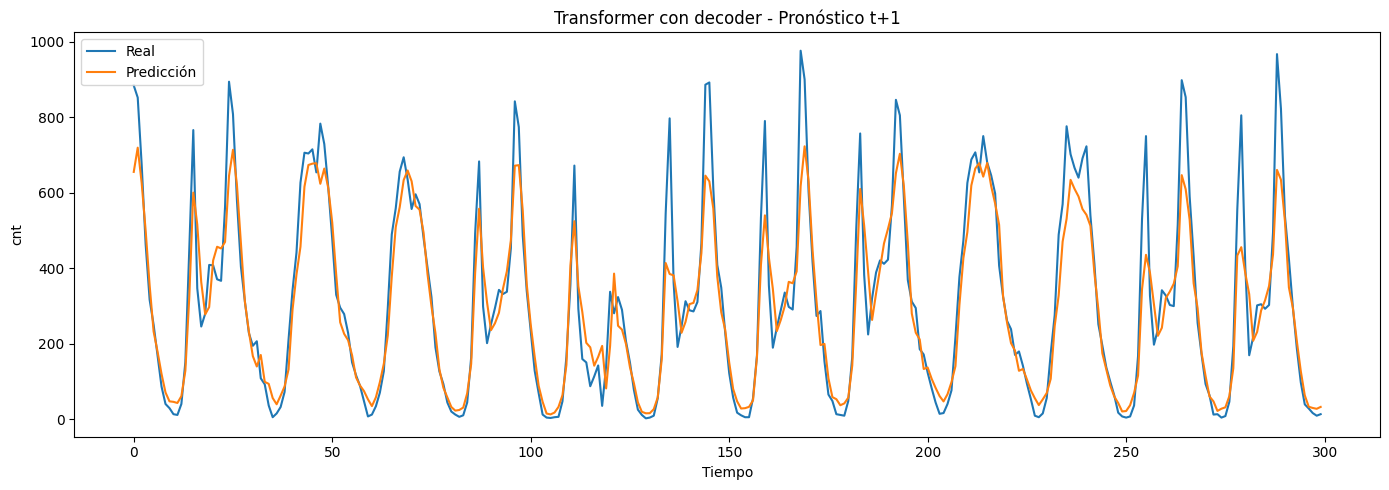


Entrenando Transformer sin decoder


Model: "Transformer_sin_decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ transformer_inputs  │ (None, 24, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 24, 64)    │        832 │ transformer_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 24, 64)    │          0 │ dense_16[0][0]    │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 24, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 24, 64)    │          0 │ dropout_23[0][0], │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 24, 128)   │          0 │ dense_17[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 24, 64)    │      8,256 │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 24, 64)    │          0 │ dense_18[0][0],   │
│                     │                   │            │ add_14[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 24, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 24, 64)    │          0 │ dropout_26[0][0], │
│                     │                   │            │ add_15[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 24, 128)   │      8,320 │ layer_normalizat

 Total params: 106,648 (416.59 KB)

 Trainable params: 106,648 (416.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - loss: 1.1924 - val_loss: 2.5745 - learning_rate: 1.0000e-04
Epoch 2/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9758 - val_loss: 2.3288 - learning_rate: 1.0000e-04
Epoch 3/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8383 - val_loss: 1.8168 - learning_rate: 1.0000e-04
Epoch 4/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7044 - val_loss: 1.4643 - learning_rate: 1.0000e-04
Epoch 5/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6416 - val_loss: 1.2919 - learning_rate: 1.0000e-04
Epoch 6/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6018 - val_loss: 1.1959 - learning_rate: 1.0000e-04
Epoch 7/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5679 - val_loss: 1.1252 - learning_rate: 1.0000e-04
Epoch 8/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5432 - val_loss: 1.0652 - learning_rate: 1.0000e-04
Epoch 9/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5187 - val_loss

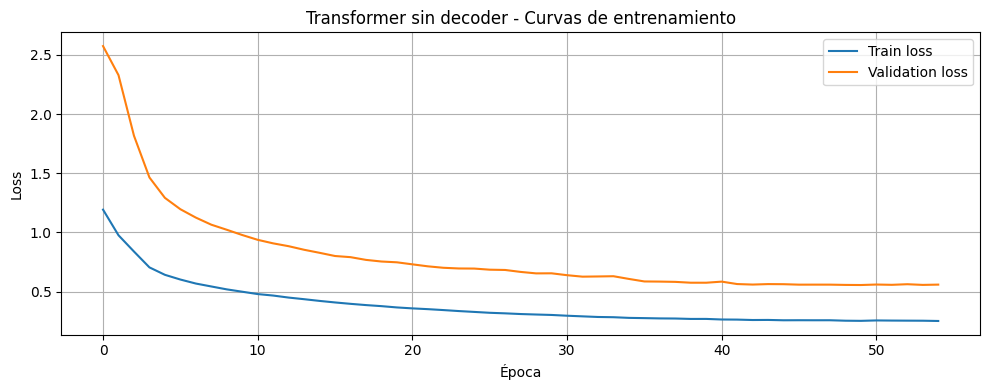

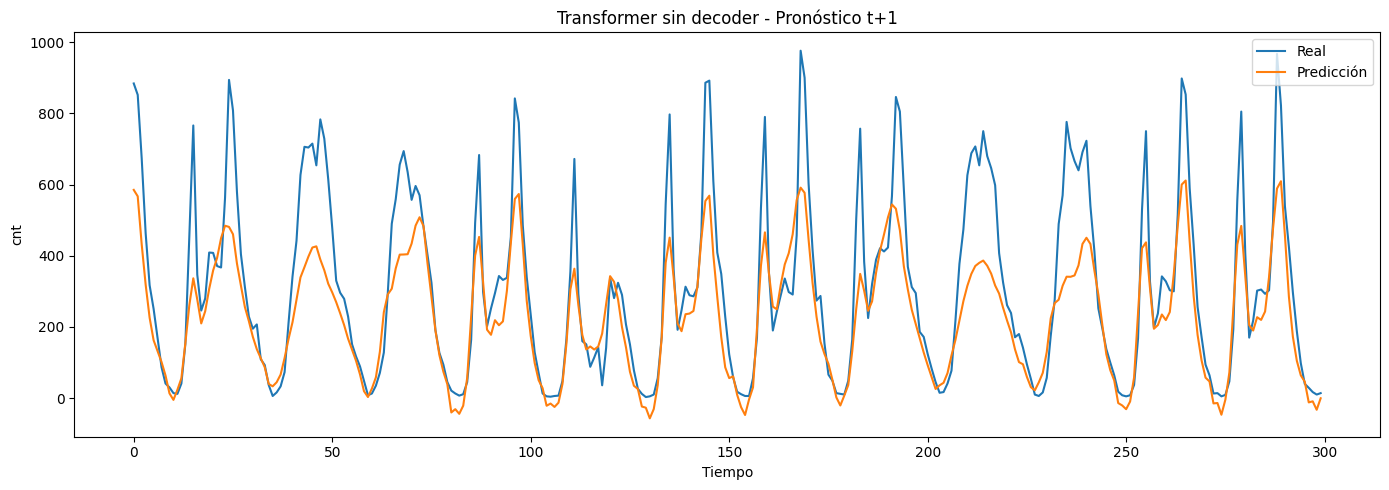


Entrenando N-BEATS


Model: "NBEATS_regularized"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_window        │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 24)        │          0 │ input_window[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_1      │ [(None, 24),      │     47,600 │ gaussian_noise[0… │
│ (NBeatsBlock)       │ (None, 24)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_subtract_1 │ (None, 24)        │          0 │ gaussian_noise[0… │
│ (Subtract)          │                   │            │ nbeats_block_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_2      │ [(None, 24),      │     47,600 │ residual_subtrac… │
│ (NBeatsBlock)       │ (None, 24)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_subtract_2 │ (None, 24)        │          0 │ residual_subtrac… │
│ (Subtract)          │                   │            │ nbeats_block_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_3      │ [(None, 24),      │     47,600 │ residual_subtrac… │
│ (NBeatsBlock)       │ (None, 24)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_sum (Add)  │ (None, 24)        │          0 │ nbeats_block_1[0… │
│                     │                   │            │ nbeats_block_2[0… │
│                     │                   │            │ nbeats_block_3[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 142,800 (557.81 KB)

 Trainable params: 142,800 (557.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - loss: 0.5723 - val_loss: 0.7671 - learning_rate: 0.0010
Epoch 2/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4437 - val_loss: 0.6766 - learning_rate: 0.0010
Epoch 3/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4065 - val_loss: 0.6203 - learning_rate: 0.0010
Epoch 4/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3812 - val_loss: 0.5928 - learning_rate: 0.0010
Epoch 5/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3632 - val_loss: 0.5604 - learning_rate: 0.0010
Epoch 6/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3481 - val_loss: 0.5447 - learning_rate: 0.0010
Epoch 7/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3374 - val_loss: 0.5232 - learning_rate: 0.0010
Epoch 8/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3283 - val_loss: 0.5046 - learning_rate: 0.0010
Epoch 9/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3203 - val_loss: 0.4985 - learning_rate: 0.0010

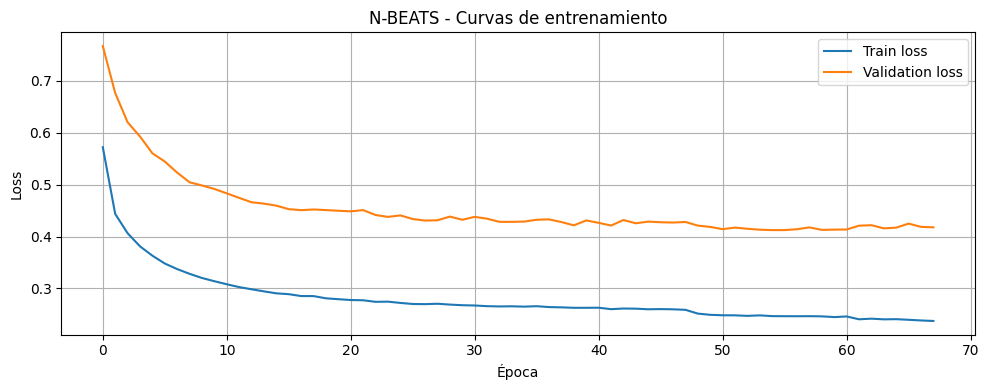

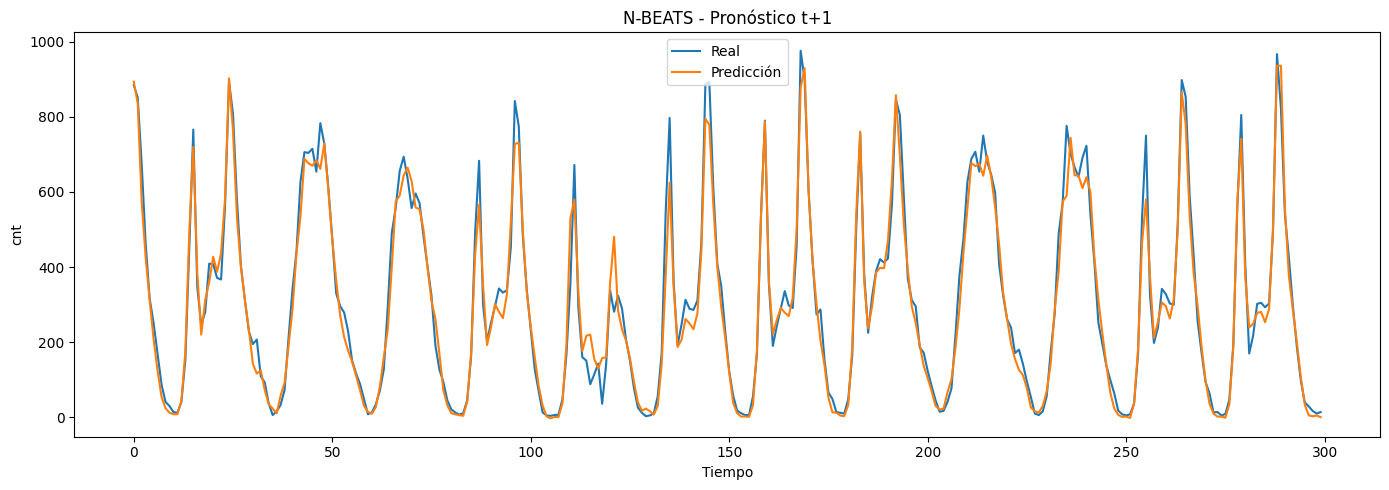


TABLA COMPARATIVA FINAL
                    Modelo        MAE           MSE        RMSE     MAPE(%)  \
0  Transformer con decoder  43.803959   4390.986328   66.264518   74.549370   
1                  N-BEATS  57.524776   8166.850586   90.370629   81.062073   
2              DeepAR-like  79.573700  13998.172852  118.313874   78.499359   
3  Transformer sin decoder  79.484398  14819.422852  121.735052  107.936218   

    sMAPE(%)  
0  35.082787  
1  42.097416  
2  49.138031  
3  52.296593  

Mejor modelo según RMSE: Transformer con decoder
RMSE del mejor modelo: 66.26451786684183

Archivo guardado: comparacion_modelos_deep_learning.csv


In [ ]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# -----------------------------
# Configuración general
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Ruta del archivo de datos
CSV_PATH = "/content/drive/MyDrive/ClassFiles/Metodos_de_Pronostico/hour.csv"

LOOKBACK = 24 # Usa las últimas 24 horas como entrada
HORIZON = 24 # Predice las siguientes 24 horas
STRIDE = 1

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 64
EPOCHS = 100 # Número máximo de épocas de entrenamiento
LEARNING_RATE_DEEPAR_NBEATS = 1e-3
LEARNING_RATE_TRANSFORMER = 1e-4

L2_REG = 1e-4
DROPOUT_RATE = 0.2
RECURRENT_DROPOUT = 0.2
USE_GAUSSIAN_NOISE = True
GAUSSIAN_NOISE_STD = 0.01

FEATURE_COLS = [
    "season", "yr", "mnth", "hr", "holiday", "weekday", "workingday",
    "weathersit", "temp", "atemp", "hum", "windspeed"
]
TARGET_COL = "cnt"

print("TensorFlow version:", tf.__version__)


# ============================================================
# 1. Funciones de carga, preparación y métricas
# ============================================================

def load_dataset():
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(
            "No se encontró el archivo hour.csv. "
            "Sube hour.csv al entorno de trabajo o colócalo en la misma carpeta del script."
        )

    df = pd.read_csv(CSV_PATH)
    df["dteday"] = pd.to_datetime(df["dteday"])
    df = df.sort_values(["dteday", "hr"]).reset_index(drop=True)
    print("Archivo usado:", CSV_PATH)
    print("Forma del dataset:", df.shape)
    return df


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.where(np.abs(y_true) == 0, 1e-8, np.abs(y_true))
    return 100.0 * np.mean(np.abs((y_true - y_pred) / denom))


def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)


def evaluate_regression(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE(%)": mape(y_true, y_pred),
        "sMAPE(%)": smape(y_true, y_pred),
    }


def inverse_transform_targets(y_scaler, y_scaled_2d):
    flat = y_scaled_2d.reshape(-1, 1)
    inv = y_scaler.inverse_transform(flat).reshape(y_scaled_2d.shape)
    return inv


def prepare_train_val_test(df):
    X_all = df[FEATURE_COLS].copy()
    y_all = df[TARGET_COL].copy()

    n = len(df)
    train_end = int(n * TRAIN_RATIO)
    val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

    X_train_df = X_all.iloc[:train_end].copy()
    y_train_df = y_all.iloc[:train_end].copy()

    X_val_df = X_all.iloc[train_end:val_end].copy()
    y_val_df = y_all.iloc[train_end:val_end].copy()

    X_test_df = X_all.iloc[val_end:].copy()
    y_test_df = y_all.iloc[val_end:].copy()

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train_df)
    X_val_scaled = x_scaler.transform(X_val_df)
    X_test_scaled = x_scaler.transform(X_test_df)

    y_train_scaled = y_scaler.fit_transform(y_train_df.values.reshape(-1, 1)).flatten()
    y_val_scaled = y_scaler.transform(y_val_df.values.reshape(-1, 1)).flatten()
    y_test_scaled = y_scaler.transform(y_test_df.values.reshape(-1, 1)).flatten()

    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
    X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=FEATURE_COLS)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)

    print("Tamaño train:", len(X_train_df))
    print("Tamaño val:", len(X_val_df))
    print("Tamaño test:", len(X_test_df))
    print("Número de variables de entrada:", len(FEATURE_COLS))

    return {
        "X_train": X_train_scaled_df,
        "X_val": X_val_scaled_df,
        "X_test": X_test_scaled_df,
        "y_train": y_train_scaled,
        "y_val": y_val_scaled,
        "y_test": y_test_scaled,
        "y_scaler": y_scaler,
    }


# ============================================================
# 2. Funciones para crear secuencias
# ============================================================

def make_multivariate_sequences(X_df, y_array, lookback=24, horizon=24, stride=1):
    X_seq, y_seq = [], []
    X_values = X_df.values

    for i in range(lookback, len(X_df) - horizon + 1, stride):
        X_seq.append(X_values[i - lookback:i])
        y_seq.append(y_array[i:i + horizon])

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)


def make_target_only_sequences(y_array, lookback=24, horizon=24, stride=1):
    X_seq, y_seq = [], []

    for i in range(lookback, len(y_array) - horizon + 1, stride):
        X_seq.append(y_array[i - lookback:i])
        y_seq.append(y_array[i:i + horizon])

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)


def make_encoder_decoder_sequences(X_df, y_array, lookback=24, horizon=24, stride=1):
    X_enc, X_dec, y_out = [], [], []
    X_values = X_df.values

    for i in range(lookback, len(X_df) - horizon + 1, stride):
        enc_window = X_values[i - lookback:i]
        target_window = y_array[i:i + horizon]

        # Entrada del decoder: último valor conocido y valores reales desplazados
        dec_input = np.concatenate([[y_array[i - 1]], target_window[:-1]])

        X_enc.append(enc_window)
        X_dec.append(dec_input.reshape(-1, 1))
        y_out.append(target_window.reshape(-1, 1))

    return (
        np.array(X_enc, dtype=np.float32),
        np.array(X_dec, dtype=np.float32),
        np.array(y_out, dtype=np.float32),
    )


# ============================================================
# 3. DeepAR-like
# ============================================================

def build_deepar_like_model(input_shape, horizon):
    inputs = layers.Input(shape=input_shape, name="inputs")
    x = inputs

    if USE_GAUSSIAN_NOISE:
        x = layers.GaussianNoise(GAUSSIAN_NOISE_STD, name="gaussian_noise")(x)

    x = layers.LSTM(
        64,
        return_sequences=True,
        dropout=DROPOUT_RATE,
        recurrent_dropout=RECURRENT_DROPOUT,
        kernel_regularizer=regularizers.l2(L2_REG),
        recurrent_regularizer=regularizers.l2(L2_REG),
        name="lstm_1",
    )(x)

    x = layers.LSTM(
        64,
        return_sequences=False,
        dropout=DROPOUT_RATE,
        recurrent_dropout=RECURRENT_DROPOUT,
        kernel_regularizer=regularizers.l2(L2_REG),
        recurrent_regularizer=regularizers.l2(L2_REG),
        name="lstm_2",
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_REG),
        name="dense_1",
    )(x)
    x = layers.Dropout(DROPOUT_RATE, name="dropout_head")(x)

    outputs = layers.Dense(horizon, activation=None, name="forecast")(x)

    model = Model(inputs=inputs, outputs=outputs, name="DeepAR_like")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_DEEPAR_NBEATS),
        loss="mse",
    )
    return model


# ============================================================
# 4. N-BEATS
# ============================================================

class NBeatsBlock(layers.Layer):
    def __init__(self, units, theta_size, backcast_size, forecast_size,
                 n_layers=3, dropout_rate=0.2, l2_reg=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.hidden_layers = []

        for _ in range(n_layers):
            self.hidden_layers.append(
                layers.Dense(
                    units,
                    activation="relu",
                    kernel_regularizer=regularizers.l2(l2_reg),
                )
            )
            self.hidden_layers.append(layers.Dropout(dropout_rate))

        self.theta_layer = layers.Dense(
            theta_size,
            activation=None,
            kernel_regularizer=regularizers.l2(l2_reg),
        )
        self.backcast_layer = layers.Dense(
            backcast_size,
            activation=None,
            kernel_regularizer=regularizers.l2(l2_reg),
        )
        self.forecast_layer = layers.Dense(
            forecast_size,
            activation=None,
            kernel_regularizer=regularizers.l2(l2_reg),
        )

    def call(self, inputs, training=False):
        x = inputs
        for layer in self.hidden_layers:
            if isinstance(layer, layers.Dropout):
                x = layer(x, training=training)
            else:
                x = layer(x)

        theta = self.theta_layer(x)
        backcast = self.backcast_layer(theta)
        forecast = self.forecast_layer(theta)
        return backcast, forecast


def build_nbeats_model(lookback, horizon):
    inputs = layers.Input(shape=(lookback,), name="input_window")
    x = inputs

    if USE_GAUSSIAN_NOISE:
        x = layers.GaussianNoise(GAUSSIAN_NOISE_STD, name="gaussian_noise")(x)

    residual = x
    forecasts = []

    for i in range(3):
        block = NBeatsBlock(
            units=128,
            theta_size=64,
            backcast_size=lookback,
            forecast_size=horizon,
            n_layers=3,
            dropout_rate=DROPOUT_RATE,
            l2_reg=L2_REG,
            name=f"nbeats_block_{i + 1}",
        )
        backcast, forecast = block(residual)
        residual = layers.Subtract(name=f"residual_subtract_{i + 1}")([residual, backcast])
        forecasts.append(forecast)

    outputs = layers.Add(name="forecast_sum")(forecasts)

    model = Model(inputs=inputs, outputs=outputs, name="NBEATS_regularized")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_DEEPAR_NBEATS),
        loss="mse",
    )
    return model


# ============================================================
# 5. Transformer sin decoder
# ============================================================

class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_len, d_model, **kwargs):
        super().__init__(**kwargs)

        positions = np.arange(sequence_len)[:, np.newaxis]
        dims = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
        angle_rads = positions * angle_rates

        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        pos_encoding = angle_rads[np.newaxis, ...]
        self.pos_encoding = tf.constant(pos_encoding, dtype=tf.float32)

    def call(self, inputs):
        seq_len = tf.shape(inputs)[1]
        return inputs + self.pos_encoding[:, :seq_len, :]


def transformer_encoder_block(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout,
    )(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)

    return x + res


def build_transformer_no_decoder_model(input_shape, horizon):
    inputs = layers.Input(shape=input_shape, name="transformer_inputs")

    x = layers.Dense(64)(inputs)
    x = PositionalEncoding(sequence_len=input_shape[0], d_model=64)(x)

    for _ in range(2):
        x = transformer_encoder_block(
            x,
            head_size=32,
            num_heads=4,
            ff_dim=128,
            dropout=0.2,
        )

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(horizon, name="forecast")(x)

    model = Model(inputs, outputs, name="Transformer_sin_decoder")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_TRANSFORMER),
        loss="mse",
    )
    return model


# ============================================================
# 6. Transformer con decoder
# ============================================================

def transformer_decoder_block(dec_inputs, enc_outputs, head_size, num_heads, ff_dim, dropout=0.1):
    # Bloque decoder del Transformer
    x = layers.LayerNormalization(epsilon=1e-6)(dec_inputs)

    # Self-attention causal
    attn_1 = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout,
    )(
        query=x,
        value=x,
        key=x,
        use_causal_mask=True,
    )
    attn_1 = layers.Dropout(dropout)(attn_1)
    out_1 = layers.Add()([attn_1, dec_inputs])

    # Cross-attention: Atención con la salida del encoder
    x2 = layers.LayerNormalization(epsilon=1e-6)(out_1)
    attn_2 = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout,
    )(
        query=x2,
        value=enc_outputs,
        key=enc_outputs,
    )
    attn_2 = layers.Dropout(dropout)(attn_2)
    out_2 = layers.Add()([attn_2, out_1])

    # Capa feed forward
    x3 = layers.LayerNormalization(epsilon=1e-6)(out_2)
    x3 = layers.Dense(ff_dim, activation="relu")(x3)
    x3 = layers.Dropout(dropout)(x3)
    x3 = layers.Dense(dec_inputs.shape[-1])(x3)

    return layers.Add()([x3, out_2])


def build_transformer_encoder_decoder_model(encoder_input_shape, decoder_input_shape):
    d_model = 64
    num_heads = 4
    ff_dim = 128
    dropout = 0.1

    encoder_inputs = layers.Input(shape=encoder_input_shape, name="encoder_inputs")
    x_enc = layers.Dense(d_model)(encoder_inputs)
    x_enc = PositionalEncoding(sequence_len=encoder_input_shape[0], d_model=d_model)(x_enc)

    for _ in range(2):
        x_enc = transformer_encoder_block(
            x_enc,
            head_size=d_model // num_heads,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout=dropout,
        )

    encoder_outputs = x_enc

    decoder_inputs = layers.Input(shape=decoder_input_shape, name="decoder_inputs")
    x_dec = layers.Dense(d_model)(decoder_inputs)
    x_dec = PositionalEncoding(sequence_len=decoder_input_shape[0], d_model=d_model)(x_dec)

    for _ in range(2):
        x_dec = transformer_decoder_block(
            x_dec,
            encoder_outputs,
            head_size=d_model // num_heads,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout=dropout,
        )

    x_dec = layers.LayerNormalization(epsilon=1e-6)(x_dec)
    outputs = layers.Dense(1, name="forecast")(x_dec)

    model = Model([encoder_inputs, decoder_inputs], outputs, name="Transformer_con_decoder")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_TRANSFORMER),
        loss="mse",
    )
    return model


# ============================================================
# 7. Entrenamiento, evaluación y gráficas
# ============================================================

def get_callbacks(patience=8):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            patience=max(2, patience // 2),
            factor=0.5,
            min_lr=1e-5,
            verbose=1,
        ),
    ]


def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(title)
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_predictions(y_true, y_pred, title, n_points=300):
    plt.figure(figsize=(14, 5))
    plt.plot(y_true[:n_points], label="Real")
    plt.plot(y_pred[:n_points], label="Predicción")
    plt.title(title)
    plt.xlabel("Tiempo")
    plt.ylabel("cnt")
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_model(model_name, y_scaler, y_true_scaled, y_pred_scaled):
    y_true = inverse_transform_targets(y_scaler, y_true_scaled)
    y_pred = inverse_transform_targets(y_scaler, y_pred_scaled)

    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    metrics = evaluate_regression(y_true_flat, y_pred_flat)
    metrics["Modelo"] = model_name

    return metrics, y_true, y_pred


def train_deepar(data):
    print("\n==============================")
    print("Entrenando DeepAR-like")
    print("==============================")

    X_train_seq, y_train_seq = make_multivariate_sequences(data["X_train"], data["y_train"], LOOKBACK, HORIZON, STRIDE)
    X_val_seq, y_val_seq = make_multivariate_sequences(data["X_val"], data["y_val"], LOOKBACK, HORIZON, STRIDE)
    X_test_seq, y_test_seq = make_multivariate_sequences(data["X_test"], data["y_test"], LOOKBACK, HORIZON, STRIDE)

    input_shape = (LOOKBACK, X_train_seq.shape[-1])
    model = build_deepar_like_model(input_shape, HORIZON)
    model.summary()

    history = model.fit(
        X_train_seq,
        y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(patience=12),
        verbose=1,
    )

    y_pred_scaled = model.predict(X_test_seq, verbose=0)
    metrics, y_true, y_pred = evaluate_model("DeepAR-like", data["y_scaler"], y_test_seq, y_pred_scaled)

    plot_history(history, "DeepAR-like - Curvas de entrenamiento")
    plot_predictions(y_true[:, 0], y_pred[:, 0], "DeepAR-like - Pronóstico t+1")

    return metrics


def train_nbeats(data):
    print("\n==============================")
    print("Entrenando N-BEATS")
    print("==============================")

    X_train_seq, y_train_seq = make_target_only_sequences(data["y_train"], LOOKBACK, HORIZON, STRIDE)
    X_val_seq, y_val_seq = make_target_only_sequences(data["y_val"], LOOKBACK, HORIZON, STRIDE)
    X_test_seq, y_test_seq = make_target_only_sequences(data["y_test"], LOOKBACK, HORIZON, STRIDE)

    model = build_nbeats_model(LOOKBACK, HORIZON)
    model.summary()

    history = model.fit(
        X_train_seq,
        y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(patience=12),
        verbose=1,
    )

    y_pred_scaled = model.predict(X_test_seq, verbose=0)
    metrics, y_true, y_pred = evaluate_model("N-BEATS", data["y_scaler"], y_test_seq, y_pred_scaled)

    plot_history(history, "N-BEATS - Curvas de entrenamiento")
    plot_predictions(y_true[:, 0], y_pred[:, 0], "N-BEATS - Pronóstico t+1")

    return metrics


def train_transformer_no_decoder(data):
    print("\n==============================")
    print("Entrenando Transformer sin decoder")
    print("==============================")

    X_train_seq, y_train_seq = make_multivariate_sequences(data["X_train"], data["y_train"], LOOKBACK, HORIZON, STRIDE)
    X_val_seq, y_val_seq = make_multivariate_sequences(data["X_val"], data["y_val"], LOOKBACK, HORIZON, STRIDE)
    X_test_seq, y_test_seq = make_multivariate_sequences(data["X_test"], data["y_test"], LOOKBACK, HORIZON, STRIDE)

    train_ds = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    input_shape = (LOOKBACK, X_train_seq.shape[-1])
    model = build_transformer_no_decoder_model(input_shape, HORIZON)
    model.summary()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=get_callbacks(patience=5),
        verbose=1,
    )

    y_pred_scaled = model.predict(X_test_seq, verbose=0)
    metrics, y_true, y_pred = evaluate_model("Transformer sin decoder", data["y_scaler"], y_test_seq, y_pred_scaled)

    plot_history(history, "Transformer sin decoder - Curvas de entrenamiento")
    plot_predictions(y_true[:, 0], y_pred[:, 0], "Transformer sin decoder - Pronóstico t+1")

    return metrics


def train_transformer_with_decoder(data):
    print("\n==============================")
    print("Entrenando Transformer con decoder")
    print("==============================")

    X_train_enc, X_train_dec, y_train_out = make_encoder_decoder_sequences(data["X_train"], data["y_train"], LOOKBACK, HORIZON, STRIDE)
    X_val_enc, X_val_dec, y_val_out = make_encoder_decoder_sequences(data["X_val"], data["y_val"], LOOKBACK, HORIZON, STRIDE)
    X_test_enc, X_test_dec, y_test_out = make_encoder_decoder_sequences(data["X_test"], data["y_test"], LOOKBACK, HORIZON, STRIDE)

    train_ds = tf.data.Dataset.from_tensor_slices(((X_train_enc, X_train_dec), y_train_out)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices(((X_val_enc, X_val_dec), y_val_out)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    encoder_input_shape = (LOOKBACK, X_train_enc.shape[-1])
    decoder_input_shape = (HORIZON, 1)
    model = build_transformer_encoder_decoder_model(encoder_input_shape, decoder_input_shape)
    model.summary()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=get_callbacks(patience=6),
        verbose=1,
    )

    y_pred_scaled = model.predict([X_test_enc, X_test_dec], verbose=0)
    y_true_scaled = y_test_out.squeeze(-1)
    y_pred_scaled = y_pred_scaled.squeeze(-1)

    metrics, y_true, y_pred = evaluate_model("Transformer con decoder", data["y_scaler"], y_true_scaled, y_pred_scaled)

    plot_history(history, "Transformer con decoder - Curvas de entrenamiento")
    plot_predictions(y_true[:, 0], y_pred[:, 0], "Transformer con decoder - Pronóstico t+1")

    return metrics


# ============================================================
# 8. Ejecución principal
# ============================================================

if __name__ == "__main__":
    df = load_dataset()
    data = prepare_train_val_test(df)

    all_results = []

    all_results.append(train_deepar(data))
    all_results.append(train_transformer_with_decoder(data))
    all_results.append(train_transformer_no_decoder(data))
    all_results.append(train_nbeats(data))

    results_df = pd.DataFrame(all_results)
    cols = ["Modelo", "MAE", "MSE", "RMSE", "MAPE(%)", "sMAPE(%)"]
    results_df = results_df[cols]
    results_df = results_df.sort_values("RMSE").reset_index(drop=True)

    print("\n======================================")
    print("TABLA COMPARATIVA FINAL")
    print("======================================")
    print(results_df)

    best_model = results_df.iloc[0]["Modelo"]
    best_rmse = results_df.iloc[0]["RMSE"]

    print("\nMejor modelo según RMSE:", best_model)
    print("RMSE del mejor modelo:", best_rmse)

    results_df.to_csv("comparacion_modelos_deep_learning.csv", index=False)
    print("\nArchivo guardado: comparacion_modelos_deep_learning.csv")
